In [1]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('default')
sns.set_palette("husl")
print("Setup complete!")

Setup complete!


# Sudan (Khartoum) - Climate Data Analysis

**Station:** Khartoum | **Elevation:** ~400m | **Period:** 2015-2026

Sudan represents the hot desert climate of the Sahel region. Khartoum sits 
at low elevation (~400m) at the confluence of the Blue and White Nile rivers. 
Extreme heat and low precipitation are expected characteristics.

In [2]:
df = pd.read_csv('../data/sudan.csv')
df['Country'] = 'Sudan'
df['Date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df.replace(-999, np.nan, inplace=True)

print(f"Shape: {df.shape}")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
df.head()

Shape: (4108, 16)
Date range: 2015-01-01 to 2026-03-31


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month,Year
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan,2015-01-01,1,2015
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan,2015-01-02,1,2015
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan,2015-01-03,1,2015
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan,2015-01-04,1,2015
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan,2015-01-05,1,2015


In [3]:
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100
print("Missing values (>0%):")
print(missing_pct[missing_pct > 0])
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values (>0%):
Series([], dtype: float64)

Duplicate rows: 0


In [4]:
df_clean = df.copy()
weather_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 
                'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M']
df_clean[weather_cols] = df_clean[weather_cols].ffill()
df_clean.to_csv('../data/sudan_clean.csv', index=False)
print("Cleaned data saved!")

Cleaned data saved!


In [5]:
print("SUDAN TEMPERATURE SUMMARY")
print(f"Mean T2M: {df_clean['T2M'].mean():.1f} C")
print(f"Max T2M: {df_clean['T2M'].max():.1f} C")
print(f"Min T2M: {df_clean['T2M'].min():.1f} C")
print(f"Std Dev: {df_clean['T2M'].std():.1f} C")
print(f"Mean Daily Range: {df_clean['T2M_RANGE'].mean():.1f} C")

# Extreme heat days
heat_days = (df_clean['T2M_MAX'] > 35).sum()
heat_days_40 = (df_clean['T2M_MAX'] > 40).sum()
print(f"Days T2M_MAX > 35C: {heat_days} ({heat_days/len(df_clean)*100:.1f}%)")
print(f"Days T2M_MAX > 40C: {heat_days_40} ({heat_days_40/len(df_clean)*100:.1f}%)")

SUDAN TEMPERATURE SUMMARY
Mean T2M: 28.8 C
Max T2M: 38.0 C
Min T2M: 13.2 C
Std Dev: 4.7 C
Mean Daily Range: 15.3 C
Days T2M_MAX > 35C: 2694 (65.6%)
Days T2M_MAX > 40C: 1113 (27.1%)


In [7]:
# Outlier Detection using Z-score
print("OUTLIER DETECTION (|Z| > 3):")
outlier_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
for col in outlier_cols:
    if col in df_clean.columns:
        z_scores = np.abs(stats.zscore(df_clean[col].dropna()))
        outliers = (z_scores > 3).sum()
        print(f"  {col}: {outliers} outliers ({(outliers/len(df_clean))*100:.1f}%)")

OUTLIER DETECTION (|Z| > 3):
  T2M: 3 outliers (0.1%)
  T2M_MAX: 6 outliers (0.1%)
  T2M_MIN: 1 outliers (0.0%)
  PRECTOTCORR: 71 outliers (1.7%)
  RH2M: 3 outliers (0.1%)
  WS2M: 4 outliers (0.1%)
  WS2M_MAX: 3 outliers (0.1%)


**Outlier Detection Results:**

The Z-score analysis (|Z| > 3) identified minimal outliers:
- T2M: 3 outliers (0.1%) - Negligible, retained
- T2M_MAX: 6 outliers (0.1%) - Negligible, retained
- T2M_MIN: 1 outlier (0.0%) - Negligible, retained
- PRECTOTCORR: 71 outliers (1.7%) - These represent rare but intense rainfall 
  events in an otherwise arid climate. Retained as they capture critical 
  flash flood events in the Sahel region
- RH2M: 3 outliers (0.1%) - Negligible, retained
- WS2M: 4 outliers (0.1%) - Negligible, retained
- WS2M_MAX: 3 outliers (0.1%) - Negligible, retained

**Decision:** All outliers were retained. With only 27% of days receiving any 
rainfall, the 71 precipitation outliers (1.7%) represent the rare but intense 
rain events that can cause flash flooding in Sudan's arid environment. All 
other outlier counts are negligible.

**Temperature Observations:**

Sudan (Khartoum) shows extreme heat characteristics:
- Mean temperature: 28.8 degrees Celsius (hottest of all 5 countries)
- Maximum recorded: 38.0 degrees Celsius
- 66 percent of days exceed 35 degrees Celsius (2,694 out of 4,108 days)
- 27 percent of days exceed 40 degrees Celsius (1,113 days)

This is dramatically hotter than Kenya (20.4 C) and Ethiopia (16.1 C). 
The elevation gradient is clear: every 100 meters of altitude reduces 
temperature by approximately 0.65 degrees Celsius.

The high standard deviation (4.7 C vs 1.4 for Kenya) reflects strong 
seasonal temperature swings typical of continental desert climates.

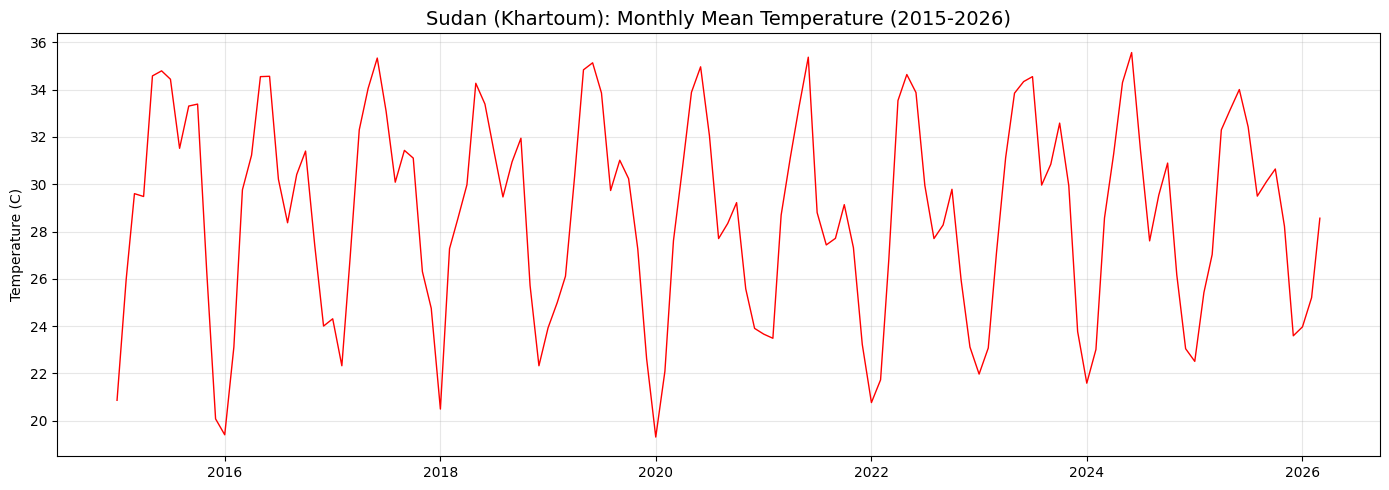

In [8]:
monthly_temp = df_clean.groupby(['Year', 'Month'])['T2M'].mean().reset_index()
monthly_temp['Date'] = pd.to_datetime(monthly_temp[['Year', 'Month']].assign(Day=1))

plt.figure(figsize=(14, 5))
plt.plot(monthly_temp['Date'], monthly_temp['T2M'], 'r-', linewidth=1)
plt.title('Sudan (Khartoum): Monthly Mean Temperature (2015-2026)', fontsize=14)
plt.ylabel('Temperature (C)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
print("SUDAN PRECIPITATION SUMMARY")
print(f"Mean daily precip: {df_clean['PRECTOTCORR'].mean():.2f} mm")
print(f"Max daily precip: {df_clean['PRECTOTCORR'].max():.2f} mm")
print(f"Days with rain: {(df_clean['PRECTOTCORR'] > 0).sum()} ({(df_clean['PRECTOTCORR'] > 0).sum()/len(df_clean)*100:.0f}%)")
print(f"Days with no rain: {(df_clean['PRECTOTCORR'] == 0).sum()} ({(df_clean['PRECTOTCORR'] == 0).sum()/len(df_clean)*100:.0f}%)")

SUDAN PRECIPITATION SUMMARY
Mean daily precip: 0.64 mm
Max daily precip: 66.49 mm
Days with rain: 1123 (27%)
Days with no rain: 2985 (73%)


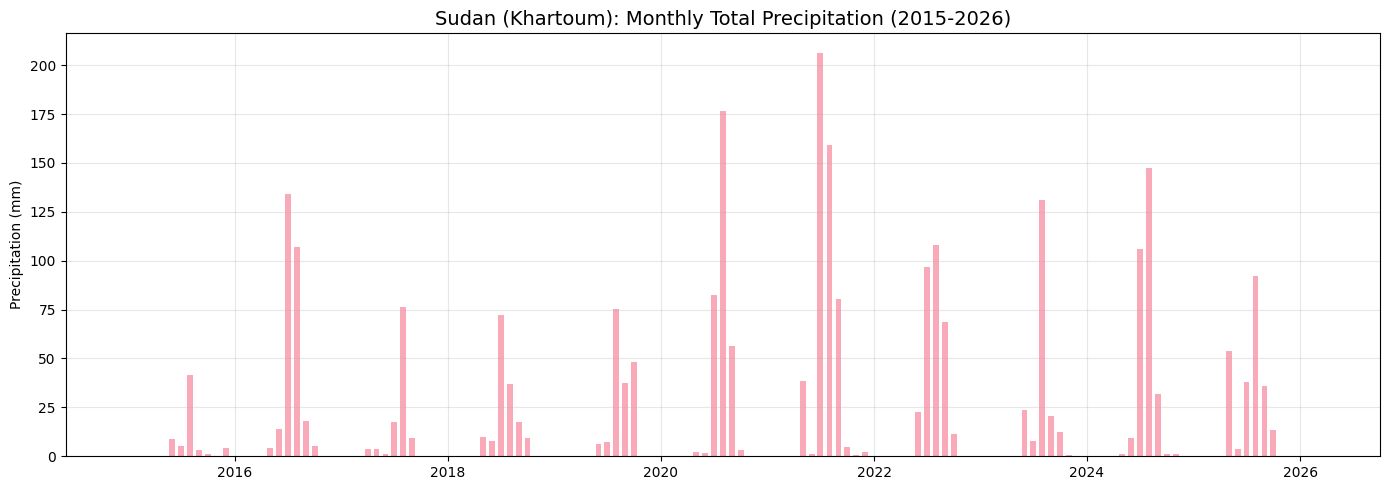

In [10]:
monthly_p = df_clean.groupby(['Year', 'Month'])['PRECTOTCORR'].sum().reset_index()
monthly_p['Date'] = pd.to_datetime(monthly_p[['Year', 'Month']].assign(Day=1))

plt.figure(figsize=(14, 5))
plt.bar(monthly_p['Date'], monthly_p['PRECTOTCORR'], width=20, alpha=0.6)
plt.title('Sudan (Khartoum): Monthly Total Precipitation (2015-2026)', fontsize=14)
plt.ylabel('Precipitation (mm)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Precipitation Observations:**

Sudan is extremely arid:
- 73 percent of days receive zero precipitation (2,985 out of 4,108)
- Mean daily precipitation: only 0.64 mm (vs 1.47 for Kenya, 3.63 for Ethiopia)
- Maximum single-day rainfall: 66.5 mm (rare intense events)

Rainfall is concentrated in a brief July-September wet season associated 
with the West African Monsoon. The combination of extreme heat and minimal 
rainfall makes Sudan the most climate-vulnerable country in this analysis 
for agriculture and water security.

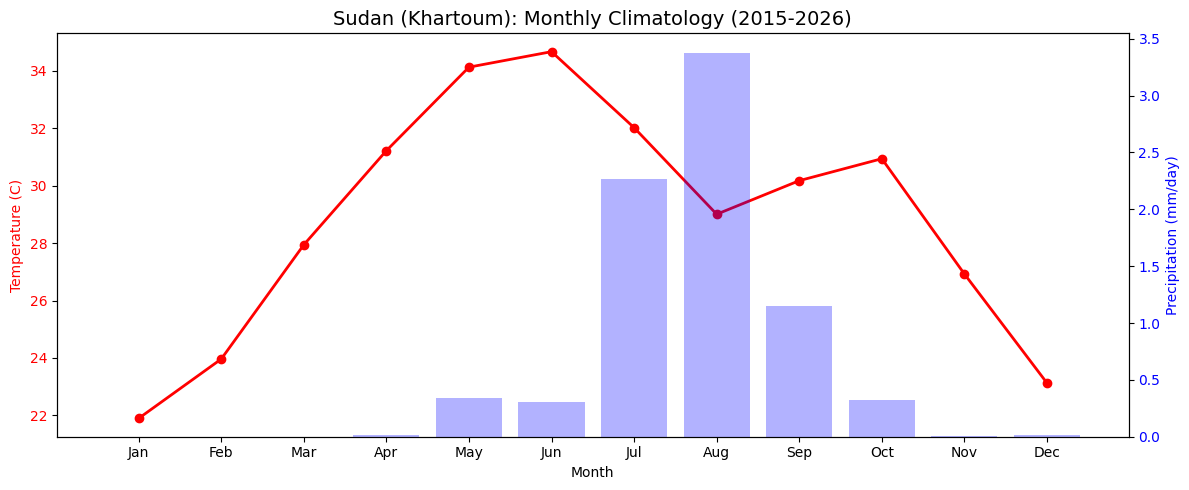

In [11]:
seasonal = df_clean.groupby('Month')[['T2M', 'PRECTOTCORR']].mean()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(seasonal.index, seasonal['T2M'], 'r-o', linewidth=2)
ax1.set_xlabel('Month')
ax1.set_ylabel('Temperature (C)', color='red')
ax1.tick_params(axis='y', labelcolor='red')

ax2 = ax1.twinx()
ax2.bar(seasonal.index, seasonal['PRECTOTCORR'], alpha=0.3, color='blue')
ax2.set_ylabel('Precipitation (mm/day)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

plt.title('Sudan (Khartoum): Monthly Climatology (2015-2026)', fontsize=14)
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.show()

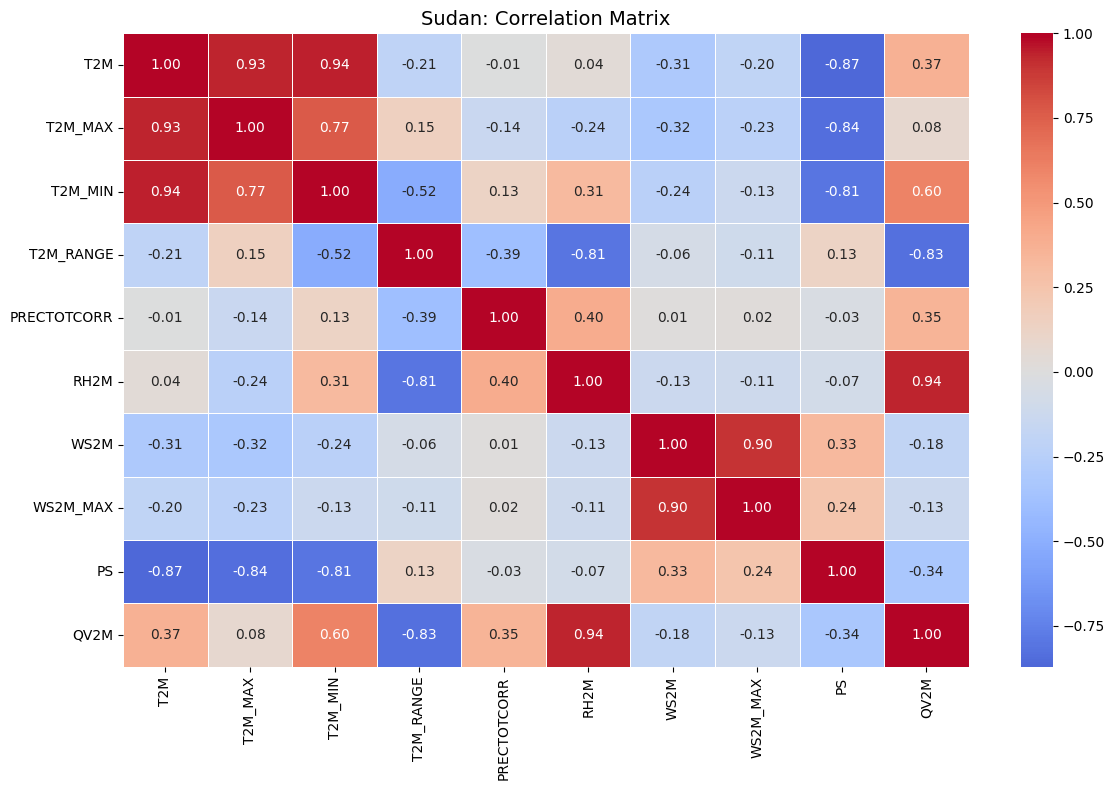

In [12]:
numeric_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 
                'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M']
corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Sudan: Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

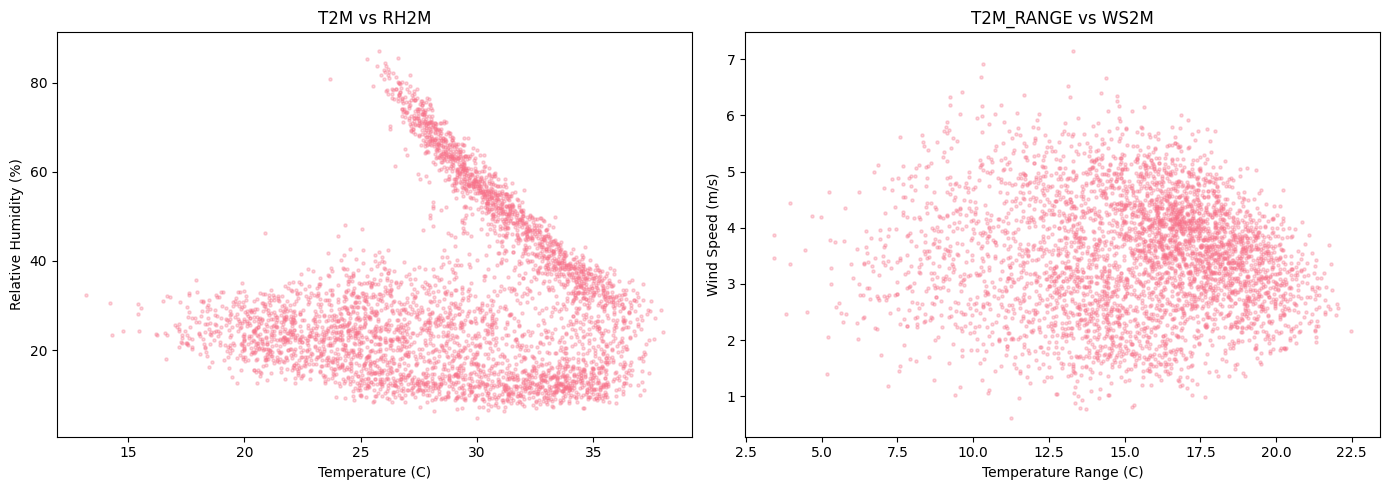

In [13]:
# Scatter plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_clean['T2M'], df_clean['RH2M'], alpha=0.3, s=5)
axes[0].set_xlabel('Temperature (C)')
axes[0].set_ylabel('Relative Humidity (%)')
axes[0].set_title('T2M vs RH2M')

axes[1].scatter(df_clean['T2M_RANGE'], df_clean['WS2M'], alpha=0.3, s=5)
axes[1].set_xlabel('Temperature Range (C)')
axes[1].set_ylabel('Wind Speed (m/s)')
axes[1].set_title('T2M_RANGE vs WS2M')

plt.tight_layout()
plt.show()

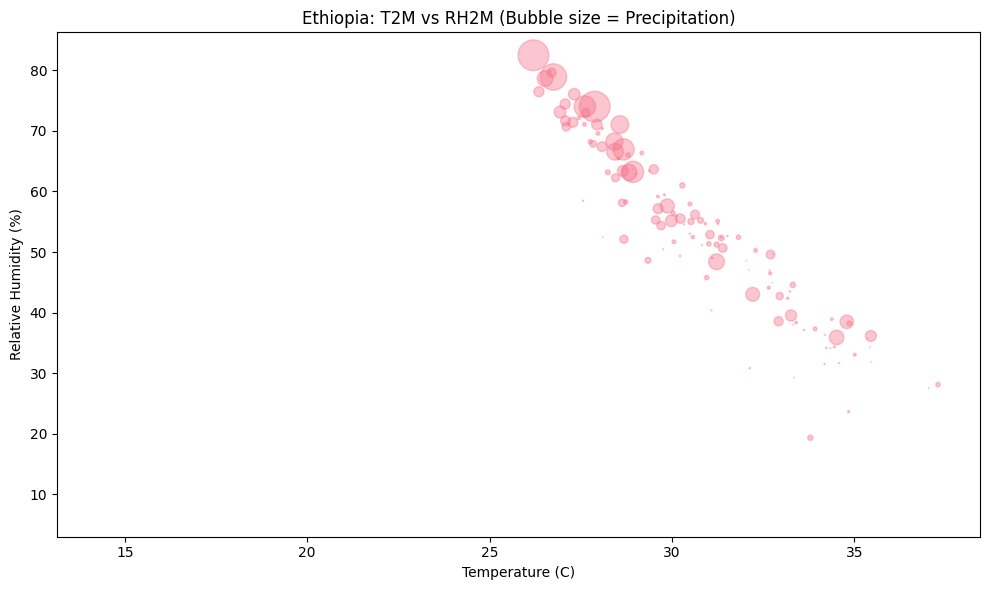

In [14]:
# Bubble chart: T2M vs RH2M, bubble size = precipitation
sample = df_clean.sample(min(500, len(df_clean)), random_state=42)
plt.figure(figsize=(10, 6))
plt.scatter(sample['T2M'], sample['RH2M'], s=sample['PRECTOTCORR']*20, alpha=0.4)
plt.xlabel('Temperature (C)')
plt.ylabel('Relative Humidity (%)')
plt.title('Ethiopia: T2M vs RH2M (Bubble size = Precipitation)')
plt.tight_layout()
plt.show()

In [15]:
# Compare Sudan with Ethiopia and Kenya
df_eth = pd.read_csv('../data/ethiopia_clean.csv')
df_ken = pd.read_csv('../data/kenya_clean.csv')

print("=" * 50)
print("THREE-COUNTRY TEMPERATURE COMPARISON")
print("=" * 50)
print(f"Sudan:    {df_clean['T2M'].mean():.1f} C (Khartoum, ~400m)")
print(f"Kenya:    {df_ken['T2M'].mean():.1f} C (Nairobi, ~1,795m)")
print(f"Ethiopia: {df_eth['T2M'].mean():.1f} C (Addis Ababa, ~2,355m)")
print()
print("PRECIPITATION COMPARISON")
print(f"Sudan:    {df_clean['PRECTOTCORR'].mean():.2f} mm/day")
print(f"Kenya:    {df_ken['PRECTOTCORR'].mean():.2f} mm/day")
print(f"Ethiopia: {df_eth['PRECTOTCORR'].mean():.2f} mm/day")

THREE-COUNTRY TEMPERATURE COMPARISON
Sudan:    28.8 C (Khartoum, ~400m)
Kenya:    20.4 C (Nairobi, ~1,795m)
Ethiopia: 16.1 C (Addis Ababa, ~2,355m)

PRECIPITATION COMPARISON
Sudan:    0.64 mm/day
Kenya:    1.47 mm/day
Ethiopia: 3.63 mm/day


## Sudan EDA Complete

Cleaned data saved to: data/sudan_clean.csv

Sudan represents the extreme end of the climate spectrum among the five 
countries: the hottest, driest, and most vulnerable to heat stress. 
This has profound implications for agriculture, water resources, and 
human health in the Sahel region.